In [1]:
import torch
import sys
sys.path.append('..')
from lightning_module import *
import matplotlib.pyplot as plt

In [2]:
# Hardcode model checkpoints for i0s1 trainings with trig rep
# model_checkpoints = [
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/4nfws2rx/checkpoints/epoch=11-val_loss=0.5918.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/e6hyv8ai/checkpoints/epoch=13-val_loss=0.5975.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/c0ze488p/checkpoints/epoch=12-val_loss=0.6009.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/36hz6jy1/checkpoints/epoch=13-val_loss=0.5908.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/we6ljacs/checkpoints/epoch=10-val_loss=0.5924.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/ki2an7jf/checkpoints/epoch=10-val_loss=0.5946.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/57w524je/checkpoints/epoch=15-val_loss=0.5983.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/lt2fnpbc/checkpoints/epoch=14-val_loss=0.5962.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/ivn7tztd/checkpoints/epoch=14-val_loss=0.6004.ckpt',
#     '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold2/checkpoints/zjets-unfolding/zk3jj6pr/checkpoints/epoch=13-val_loss=0.5915.ckpt'
# ]

In [76]:
# Hardcode model checkpoint for i0s1 trainings without trig rep
model_checkpoints = [
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/r6jzb7tz/checkpoints/epoch=12-val_loss=0.5850.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/2s0zc2wi/checkpoints/epoch=23-val_loss=0.5890.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/6dktath2/checkpoints/epoch=17-val_loss=0.5867.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/ccjqmhmd/checkpoints/epoch=13-val_loss=0.5837.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/zuhmrk6z/checkpoints/epoch=11-val_loss=0.5924.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/vwej66wn/checkpoints/epoch=15-val_loss=0.5882.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/28twe5xp/checkpoints/epoch=20-val_loss=0.5870.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/wskzt9i0/checkpoints/epoch=12-val_loss=0.5846.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/ok80jn44/checkpoints/epoch=15-val_loss=0.5820.ckpt',
    '/global/homes/k/kgreif/zjets/launch_dirs/zjets_omnifold1/checkpoints/zjets-unfolding-notrig/58mzd90j/checkpoints/epoch=16-val_loss=0.5891.ckpt',
]

In [77]:
# Load models from checkpoint
models = [LOfTransformer.load_from_checkpoint(ck) for ck in model_checkpoints]

Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!
Batch normalization disabled in embeddings!


In [78]:
# Load data module
d_module_reco = LOfData(
    source_file='../dataloc/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test_Mar0723.root',
    target_file='../dataloc/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Apr8_1_All.root',
    batch_size=1,
    load_all=True,
    testing=False,
    use_truth=False
)


We have a fraction 0.8091369462673238 of good events in this file
/global/homes/k/kgreif/.conda/envs/zjets/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:245: RuntimeWarning: invalid value encountered in log
  return impl(*broadcasted_args, **(kwargs or {}))
We have a fraction 1.0 of good events in this file
We have 382352 source events and 247252 target events
We have 629604 events in total


In [89]:
loader = iter(d_module_reco.predict_dataloader())

In [98]:
# Get the first event
kinematics, _, mask, _, plotting = next(loader)

In [99]:
# Find leading / sub-leading muon phi
leading_muon_phi = kinematics[0,2,0].cpu().numpy()
subleading_muon_phi = kinematics[0,2,1].cpu().numpy()
print('Leading muon phi:', leading_muon_phi)
print('Subleading muon phi:', subleading_muon_phi)

Leading muon phi: 2.2308874
Subleading muon phi: 1.5379447


In [100]:
# Find leading / sub-leaeding jet phi
leading_jet_phi = plotting[0,12].cpu().numpy()
subleading_jet_phi = plotting[0,13].cpu().numpy()
print('Leading jet phi:', leading_jet_phi)
print('Subleading jet phi:', subleading_jet_phi)

Leading jet phi: -1.1907618
Subleading jet phi: -1.6032423


In [101]:
# Repeat event 200 times along first axis
kinematics = torch.tile(kinematics, (200, 1, 1))
mask = torch.tile(mask, (200, 1, 1))

In [102]:
# Now shift the phi coordinate of the leading muon
mphi = kinematics[:,2,0]
mphi_shift = torch.linspace(-np.pi, np.pi, 200) 
new_phi = mphi + mphi_shift
new_phi[new_phi > np.pi] -= 2*np.pi
new_phi[new_phi < -np.pi] += 2*np.pi
kinematics[:,2,0] = new_phi

In [68]:
# Calculate sin phi and cos phi for this event
phi = kinematics[:,2:3,:]
sin_phi = torch.sin(phi)
cos_phi = torch.cos(phi)
print(phi.shape)

torch.Size([200, 1, 84])


In [69]:
# Build the kinematics array with trig rep
kinematics_trig = torch.cat([kinematics[:,:2,:], sin_phi, cos_phi, kinematics[:,3:,:]], dim=1)
print(kinematics_trig.shape)

torch.Size([200, 11, 84])


In [85]:
print(kinematics_trig.shape)
print(kinematics_trig[0,2,:])
print(kinematics_trig[0,3,:])
print(kinematics_trig[0,4,:])

torch.Size([200, 11, 84])
tensor([-0.7795,  0.5168, -0.5405, -0.5268, -0.5245, -0.5149, -0.6215, -0.9443,
        -0.6491, -0.5318, -0.6527, -0.6273, -0.9223, -0.5228, -0.9238, -0.6146,
        -0.4342, -0.5922, -0.9569, -0.5933, -0.9041, -0.4274, -0.5176, -0.8572,
        -0.7000, -0.4475,  0.8953,  0.9832, -0.5175,  0.9834, -0.9932, -0.9622,
        -0.5048, -0.4544, -0.4486,  0.4980, -0.5021, -0.9914,  0.9853,  0.9116,
        -0.8262,  0.9617, -0.4860,  0.2605,  0.9263, -0.9665, -0.9994, -0.9516,
        -0.8119, -0.1298,  0.3494, -0.6152, -0.6626, -0.6447, -0.7601, -0.6792,
         0.0133, -0.8551, -0.9162, -0.3670, -0.9739,  0.3584,  0.7131,  0.1332,
        -0.9979, -0.4398, -0.4917,  0.4790, -0.4441, -0.1619, -0.1839,  0.2061,
        -0.4655, -0.7679,  0.7958, -0.5385,  0.5719,  0.7324, -0.2599, -0.6836,
        -0.9795, -0.4920, -0.8633, -0.8733])
tensor([-0.6264,  0.8561, -0.8414, -0.8500, -0.8514, -0.8572, -0.7834,  0.3292,
        -0.7607, -0.8468, -0.7576, -0.7788,  0.38

In [103]:
# Run inference with the shifted phis
results = []
for model in models:
    model.eval()
    with torch.no_grad():
        result = model(kinematics.to(device='cuda:0'), mask.to(device='cuda:0'))
        results.append(result)

In [104]:
# Evaluate mean and median outputs
mean_output = torch.mean(torch.stack(results), dim=0)
median_output = torch.median(torch.stack(results), dim=0).values

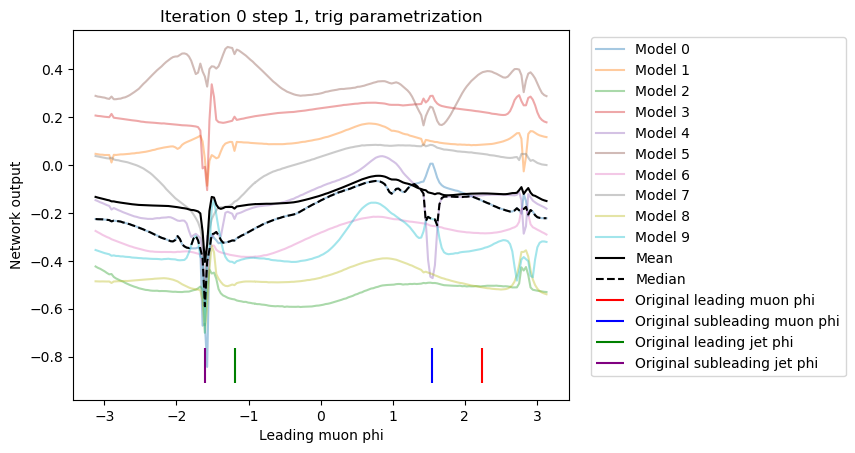

In [105]:
# Make a plot of network output versus the leading muon phi
new_phi, ind = torch.sort(new_phi)
m1_phi = new_phi.numpy()

ax = plt.gca()
for i, r in enumerate(results):
    r = r[ind]
    plt.plot(m1_phi, r.cpu().numpy(), label=f'Model {i}', alpha=0.4)

og_bottom = ax.get_ylim()[0]
top = og_bottom + 0.1*(ax.get_ylim()[1] - ax.get_ylim()[0])
plt.plot(m1_phi, mean_output[ind].cpu().numpy(), label='Mean', color='black')
plt.plot(m1_phi, median_output[ind].cpu().numpy(), label='Median', color='black', linestyle='--')
plt.vlines(leading_muon_phi, og_bottom, top, color='red', label='Original leading muon phi')
plt.vlines(subleading_muon_phi, og_bottom, top, color='blue', label='Original subleading muon phi')
plt.vlines(leading_jet_phi, og_bottom, top, color='green', label='Original leading jet phi')
plt.vlines(subleading_jet_phi, og_bottom, top, color='purple', label='Original subleading jet phi')
plt.xlabel('Leading muon phi')
plt.ylabel('Network output')
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
plt.title('Iteration 0 step 1, trig parametrization')
plt.show()
